# Echo Sound Effect

In this activity, you will build an echo effect by storing old output samples in memory and mixing them back into the current audio.

## Understanding Difference Equations

A **difference equation** is a mathematical formula that calculates the current output signal $y[n]$ based on the current and past input samples, such as $x[n]$, $x[n-1]$, etc.

Instead of thinking of it as a vague or complicated formula, it’s helpful to think of the input signal $x[n]$ like an array in programming languages such as Python, Java, or C/C++. Each index $n$ represents a point in time, and each value in the array is a sound sample taken at that moment.

For example:
- $x[n]$ is the current sample  
- $x[n-1]$ is the previous sample  
- $x[n-2]$ is the sample before that  

Using this idea, a difference equation computes the output $y[n]$ by combining different elements of this “array” through addition, subtraction, and multiplication to produce a new signal.

## How to Make Echoes

The difference equation used to create an echo effect is:

$$
y[n] = x[n] + \frac{1}{2} y[n-D]
$$

where: 
- $x[n]$ is the current sound sample **(input)**
- $y[n-D]$ is the **output** from $D$ samples ago  
- $\frac{1}{2}$ scales the delayed signal so the echo is quieter and fades over time  

> Note: $D$ represents a delay in **number of samples**, not seconds. The actual time delay depends on the sampling rate. For example, at a sampling rate of 48 kHz, $D = 240{,}000$ corresponds to 5 seconds.


### Why do we store output samples and not input samples?

We do this to create **fading echoes**. 

The easiest way to understand this is by tracing an example: 

Suppose the input signal over time is A, B, then C and the delay is 3 seconds.

---

**At 0 seconds:**  
Input = A  

$y[n] = x[n] + \frac{1}{2} y[n-D] \\= A + 0$ 

(No delayed signal yet because we're at the start)

---

**After one full delay (3 seconds):**  
Input = B  

$y[n] = x[n] + \frac{1}{2} y[n-D] \\= B + \frac{1}{2}A $

---

**After two full delays (6 seconds):**  
Input = C  

$y[n] = x[n] + \frac{1}{2} y[n-D] \\= C + \frac{1}{2}(B + \frac{1}{2}A) \\= C + \frac{1}{2}B + \frac{1}{4}A$ 

---

Each time the signal is delayed again, it gets multiplied by another $\frac{1}{2}$, which is why it keeps getting quieter.

Because we store output samples (which already include previous echoes), each new echo contains older echoes inside it. This is what creates the gradual fading effect.

If we stored input samples instead, we would only hear a single repeat with no decay.

## Implementing the Echo Module


Open `echo.sv`. 

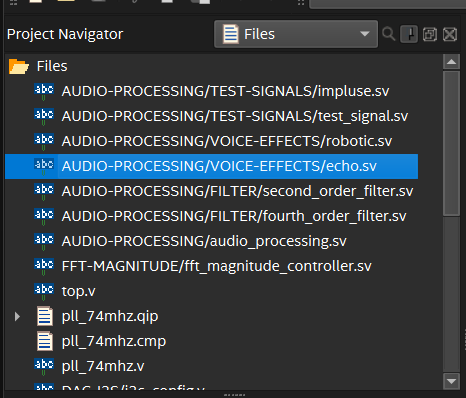

### Required signals
You will need the following signals: 
- `prev_samples`: an array to store previous **output** samples
- `index`: tracks the current position in the array 
- `delayed_sample`: temporarily holds the delayed output sample 

#### Hint: 
- `$clog2(DELAYED_SAMPLES)` gives you enough bits for `index` to count through the whole array

### How the code matches the equation
Recall the echo equation:
$$
y[n] = x[n] + \frac{1}{2} y[n-D]
$$

In the code: 
- `data_in` is $x[n]$, the current input sample
- `prev_samples[index]` is the delayed output, $y[n - D]$
- `data_out` is $y[n]$
- After computing `data_out`, we store it back into the array so it can be reused later
- The index moves forward once per sample and wraps back to `0`, which makes the array behave like a circular buffer

If you already know what a circular buffer is, one full pass through the buffer corresponds to the full delay time.

If you do not, that is totally fine. You can think of it as a normal array where the index wraps back to `0` after it reaches `DELAYED_SAMPLES - 1.`

#### Hint: 
- use `>>> 1` to divide by 2 (this is more hardware-friendly than `/ 2`)

### Starter Skeleton

If you are new to SystemVerilog syntax, you can use the reference sheet here: [SystemVerilog Reference Sheet](reference_sheet.ipynb)

You can use this skeleton to help you: 

```systemverilog
module echo #(
    parameter SAMPLE_WIDTH = 16,
    parameter DELAYED_SAMPLES = 9000
) (
    input  logic clk,
    input  logic reset,
    input  logic signed [SAMPLE_WIDTH-1:0] data_in,
    input  logic data_valid,
    output logic signed [SAMPLE_WIDTH-1:0] data_out
);
    // ------------------------------------------------------------------
    // Internal signals and registers
    // ------------------------------------------------------------------

    // TODO: create index variable
    // TODO: create delay array
    // TODO: create delayed sample variable

    // ------------------------------------------------------------------
    // Sequential logic
    // ------------------------------------------------------------------

    always_ff @(posedge clk) begin
        if (reset) begin
            // TODO: set index to 0
            // TODO: set data_out to 0

        // Only update the echo when a new audio sample is ready
        end else if (data_valid) begin
            // TODO: read delayed sample

            // TODO: compute output y[n] = x[n] + 0.5 y[n-D]
            
            // TODO: store output into the array

            // TODO: incredment the index
            // TODO: when the index reaches `DELAYED_SAMPLES - 1`, wrap it back to `0`
            
        end
    end
endmodule
```

### Integration
Connect the `echo` module inside `audio_controller` so the processed audio is sent to the output.

### Testing and validation

If it is correct you should hear your voice being echoed back at you.

#### Optional: Using `test_signal` (for debugging)

##### Using the `test_signal` module

The test_signal module generates a known signal, which makes it easier to debug your echo implementation.

Example instantiation:
```systemverilog
test_signal u_test_signal (
    .clk(clk_50),
    .reset(reset),
    .out_audio(test_audio),
    .out_valid(test_valid)
);
```

How to use it:
1. Go to `audio_controller` 
2. Instantiate the test_signal module
2. Connect the input of your `echo` module to `test_signal` instead of the microphone input
3. Connect an oscilloscope to the output signal (probe tip to signal, ground clip to GND)

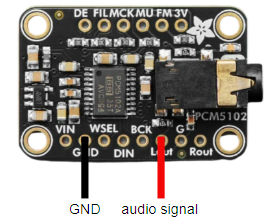

##### Oscilloscope settings 
- Press `Auto Scale`
- For a cleaner signal, you can press the `Run/Stop` button to pause the oscilloscope, then press it again to resume
- This produces repeated echoes that are easy to see on the oscilloscope

The first image shows the initial input test signal, and the second shows the correctly echoed output.

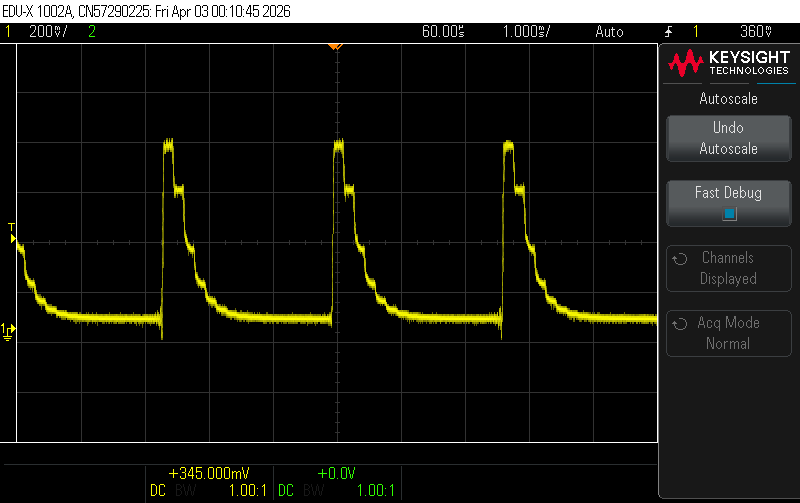 
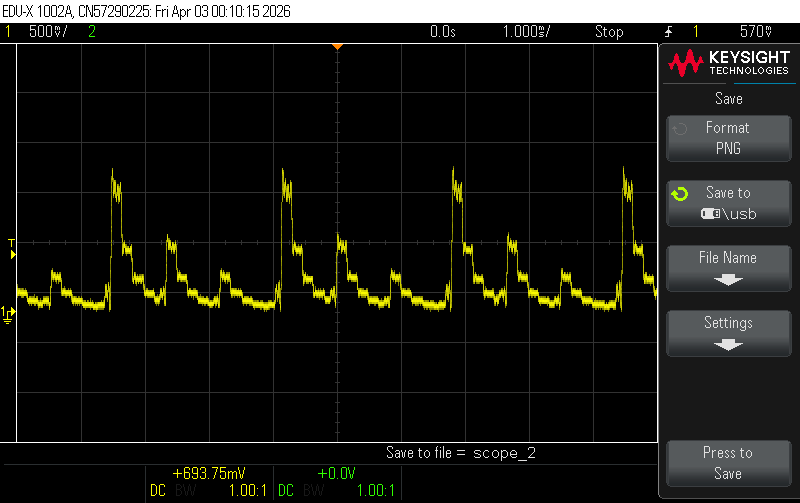

When testing this way, you will hear a long beep and see a series of vertical lines on the monitor. This is expected behavior. You may want to unplug your speakers or headphones, as the sound can be loud and unpleasant.

**Important:** Reconnect the echo input back to the microphone after you are done debugging, or you will not hear live audio.

## Challenge

### 1. Turn the Effect On/Off
Inside `audio_controller`, add logic so you can turn the echo effect on and off using one of the switches on the board.

### 2. Change the Decay
Adjust how quickly the echo fades by changing the shift amount used to scale the delayed signal.

For example:
- `>>> 1` makes the echo louder and fade more slowly
- `>>> 2` makes the echo quieter and fade more quickly

### 3. Change the Delay
Try increasing or decreasing `DELAYED_SAMPLES` to change how long it takes before you hear the echo.

For example:
- Larger `DELAYED_SAMPLES` creates a longer delay before the echo
- Smaller `DELAYED_SAMPLES` creates a  shorter delay before the echo

---
|**Back:** [Set-up](setup.ipynb) | [Top](#echo-sound-effect)| **Next:** [Robotic Voice Effect](robotic_voice.ipynb)|
|---------------------------------------|-------------------------------|------------------------------------------------------|